In [2]:
import duckdb
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import os
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from pathlib import Path
os.chdir(Path().resolve().parent)

In [4]:
# подключаемся к базе
con = duckdb.connect('notebooks/credit_risk.db')

#настройка mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
artifact_path = "file:///risk-project"
experiment_name = "credit_risk_pd"
try:
    experiment_id = mlflow.create_experiment(
        experiment_name,
        artifact_location=artifact_path
    )
except mlflow.exceptions.MlflowException:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id


In [5]:
# только дефолтные кредиты
df = con.execute("""
    SELECT *
    FROM mart.features
    WHERE is_default = 1
      AND lgd_actual IS NOT NULL
      AND lgd_actual BETWEEN 0 AND 1
""").df()

print(f"Дефолтных кредитов: {df.shape[0]}")
print(f"\nРаспределение LGD:")
print(df['lgd_actual'].describe().round(3))

Дефолтных кредитов: 267774

Распределение LGD:
count    267774.000
mean          0.697
std           0.219
min           0.000
25%           0.566
50%           0.747
75%           0.872
max           1.000
Name: lgd_actual, dtype: float64


In [6]:
FEATURES_LGD = [
    'dti', 'fico_avg', 'annual_inc', 'loan_amnt',
    'installment', 'open_acc', 'revol_util', 'total_acc',
    'loan_to_income', 'payment_to_income', 'term_months',
    'home_ownership', 'purpose'
]

df_lgd = df[FEATURES_LGD + ['lgd_actual']].dropna()
df_lgd = pd.get_dummies(df_lgd,
                         columns=['home_ownership', 'purpose'],
                         drop_first=True)

FEATURES_LGD_ENC = [c for c in df_lgd.columns if c != 'lgd_actual']

X = df_lgd[FEATURES_LGD_ENC]
y = df_lgd['lgd_actual']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 214075, Test: 53519


In [7]:
def compute_lgd_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    # среднее отклонение предсказанного LGD от фактического
    bias = np.mean(y_pred - y_true)
    return {
        "RMSE": round(rmse, 4),
        "R2":   round(r2, 4),
        "MAE":  round(mae, 4),
        "Bias": round(bias, 4)
    }

In [8]:
# baseline - линейная регрессия
mlflow.set_experiment(experiment_name)
with mlflow.start_run(run_name="lgd_linear_baseline"):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test).clip(0, 1)  # обрезаем выход в [0,1]
    metrics_lr = compute_lgd_metrics(y_test.values, y_pred_lr)
    
    mlflow.log_params({"model": "LinearRegression"})
    mlflow.log_metrics(metrics_lr)
    mlflow.sklearn.log_model(lr, "model")
    
    print("Линейная регрессия:")
    for k, v in metrics_lr.items():
        print(f"  {k}: {v}")

2026/04/10 14:01:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:01:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Линейная регрессия:
  RMSE: 0.2042
  R2: 0.1331
  MAE: 0.1628
  Bias: 0.001


In [9]:
# challenger - градиентный бустинг
with mlflow.start_run(run_name="lgd_gbm_challenger"):
    gbm = GradientBoostingRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    gbm.fit(X_train, y_train)
    y_pred_gbm = gbm.predict(X_test).clip(0, 1)
    metrics_gbm = compute_lgd_metrics(y_test.values, y_pred_gbm)
    
    mlflow.log_params({
        "model": "GradientBoosting",
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05
    })
    mlflow.log_metrics(metrics_gbm)
    mlflow.sklearn.log_model(gbm, "model")
    
    print("\nGradient Boosting:")
    for k, v in metrics_gbm.items():
        print(f"  {k}: {v}")

2026/04/10 14:03:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 14:03:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Gradient Boosting:
  RMSE: 0.2023
  R2: 0.1491
  MAE: 0.1613
  Bias: 0.0009


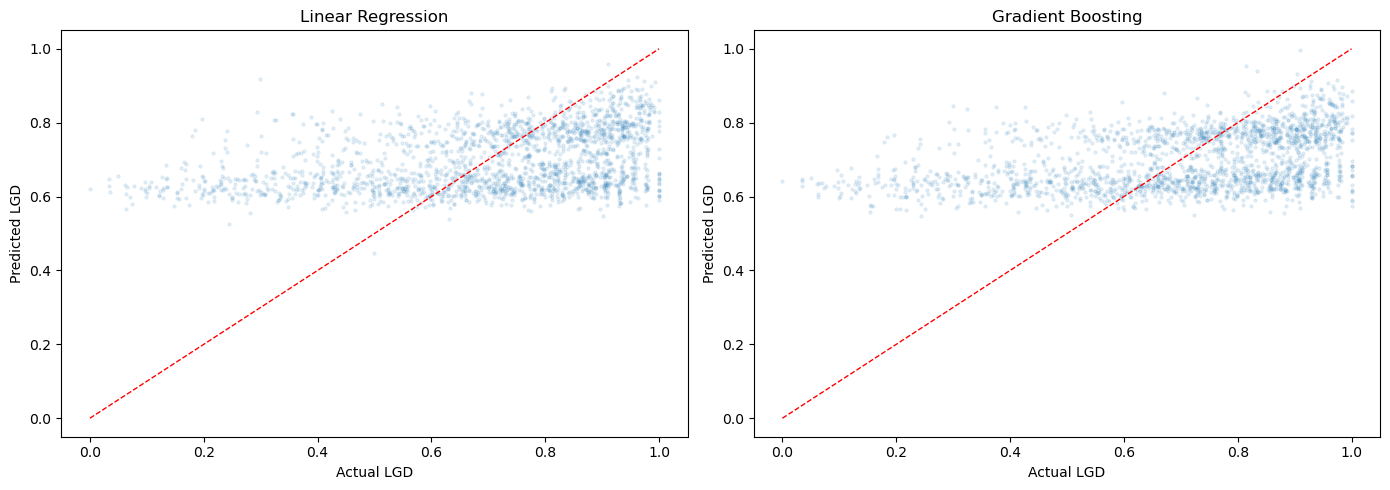

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [y_pred_lr, y_pred_gbm],
    ['Linear Regression', 'Gradient Boosting']
):
    ax.scatter(y_test[:2000], preds[:2000], alpha=0.1, s=5)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
    ax.set_xlabel('Actual LGD')
    ax.set_ylabel('Predicted LGD')
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [11]:
# для расчёта EL будем использовать константный LGD
LGD_CONSTANT = df['lgd_actual'].mean()
LGD_MODEL = gbm  # используем GBM там где нужна индивидуальная оценка

print(f"Константный LGD (pooled): {LGD_CONSTANT:.3f}")
print(f"GBM LGD RMSE: {metrics_gbm['RMSE']:.4f}")
print(round(df['lgd_actual'].std(),4))

Константный LGD (pooled): 0.697
GBM LGD RMSE: 0.2023
0.2187


In [12]:
con.close()